# N15 — Pit Stop Duration Model

Pit stop duration is one of the few race variables that's **fully controllable by the team** — and also one where a 2-second mistake can cost a position. This notebook builds a quantile regression model that predicts the P10/P50/P90 distribution of **physical pit stop time** for a given car, compound, circuit, and race context.

## Modeling approach — design evolution

**First attempt (total pit lane time):** The initial target was `pit_duration_s = PitOutTime − PitInTime`, which includes the full pit lane traversal (~17–24 s, circuit-fixed) plus the physical stop (~2–8 s, team-dependent). This approach yielded P50 MAE ~2.3 s on test, identical to a simple team × circuit median baseline. The reason: the dominant signal (pit lane length) is already captured by the `circuit` feature, leaving the model nothing new to learn. 2.3 s of error on a 23 s stop is also disproportionately large relative to the physically meaningful variation.

**Final approach (physical stop estimate):** We decompose the total time as:

```
pit_duration_s  =  circuit_traversal  +  physical_stop_est
circuit_traversal = min(pit_duration_s for circuit, across train)  −  2.0 s
physical_stop_est = pit_duration_s  −  circuit_traversal
```

The `2.0 s` floor represents the fastest possible physical stop (~Red Bull record, 2023). `physical_stop_est` is now in the range **0.5–15 s** — the component that varies by team quality, crew errors, and race conditions. Predicting this is both harder and more meaningful. At inference time the Strategy Agent reconstructs total time as `physical_stop_pred + circuit_traversal_lookup[circuit]`.

**Why quantile regression?** Even for the physical stop, the distribution has a long right tail (unsafe release, jack problems). P10/P50/P90 gives the Strategy Agent a best/worst-case window rather than a single overconfident point estimate.

**Data source:** FastF1 `laps.PitInTime` / `laps.PitOutTime` (2023–2025 races).

## Notebook structure

| Step | Content |
|------|---------|
| 0 | Setup + FastF1 download + EDA (distributions, outlier inspection) |
| 1 | Feature engineering |
| 2 | Baseline + circuit traversal decomposition |
| 3 | HistGradientBoostingRegressor P10 / P50 / P90 on `physical_stop_est` |
| 4 | Evaluation + residuals + feature importance |
| 5 | Export models + `model_config.json` |

---

In [1]:
# ── Step 0 · Setup + FastF1 pit data download ─────────────────────────────
import sys
from pathlib import Path
repo_root = Path.cwd()
while not (repo_root / ".git").exists():
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import fastf1
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder

import logging
logging.getLogger("fastf1").setLevel(logging.WARNING)


In [2]:
CACHE_DIR  = repo_root / "data" / "cache" / "fastf1"
EXPORT_DIR = repo_root / "data" / "models" / "pit_prediction"
PROC_DIR   = repo_root / "data" / "processed" / "pit_labeled"
OUTPUTS    = repo_root / "notebooks" / "strategy" / "pit_prediction" / "outputs"

for d in [CACHE_DIR, EXPORT_DIR, PROC_DIR, OUTPUTS]:
    d.mkdir(parents=True, exist_ok=True)

fastf1.Cache.enable_cache(str(CACHE_DIR))

In [3]:
YEARS = [2023, 2024, 2025]

# Circuits known for tight/confined pit boxes — real causal signal for physical stop time
TIGHT_PIT_BOX_CIRCUITS = {"Monaco Grand Prix", "Singapore Grand Prix", "Hungarian Grand Prix"}


def collect_pit_data(years):
    records = []
    for year in years:
        schedule = fastf1.get_event_schedule(year, include_testing=False)
        gp_names = schedule[schedule["EventFormat"] != "testing"]["EventName"].tolist()
        for gp in gp_names:
            try:
                session = fastf1.get_session(year, gp, "R")
                session.load(laps=True, telemetry=False, weather=False, messages=False)
            except Exception as e:
                print(f"  SKIP {year} {gp}: {e}")
                continue

            laps = session.laps[["Driver", "Team", "LapNumber", "Compound",
                                  "TyreLife", "PitInTime", "PitOutTime",
                                  "TrackStatus"]].copy()

            pit_in  = laps[laps["PitInTime"].notna()][
                ["Driver", "Team", "LapNumber", "Compound", "TyreLife",
                 "PitInTime", "TrackStatus"]
            ].copy()
            pit_out = laps[laps["PitOutTime"].notna()][
                ["Driver", "LapNumber", "PitOutTime", "TyreLife"]
            ].copy()

            # PitInTime on lap N, PitOutTime on lap N+1
            pit_in["LapNumber_out"] = pit_in["LapNumber"] + 1
            merged = pit_in.merge(
                pit_out.rename(columns={
                    "LapNumber": "LapNumber_out",
                    "TyreLife":  "TyreLife_out"
                }),
                on=["Driver", "LapNumber_out"], how="inner"
            )

            merged["pit_duration_s"] = (
                merged["PitOutTime"] - merged["PitInTime"]
            ).dt.total_seconds()

            # Filter drive-throughs: genuine tyre change resets TyreLife to ≤5.
            # Threshold relaxed from 3→5 to recover FastF1 artifacts where TyreLife
            # resets to 4-5 due to transponder sync delay on the out-lap.
            n_raw = len(merged)
            merged = merged[merged["TyreLife_out"] <= 5].copy()
            n_filtered = len(merged)
            if n_raw != n_filtered:
                print(f"    removed (TyreLife_out > 5): {n_raw - n_filtered}")

            merged["Year"]    = year
            merged["GP_Name"] = gp

            cols = ["Year", "GP_Name", "Team", "Driver", "LapNumber",
                    "Compound", "TyreLife", "pit_duration_s", "TrackStatus"]
            records.append(merged[cols])
            print(f"  {year} {gp}: {n_filtered} pit stops")

    return pd.concat(records, ignore_index=True)

In [4]:
df_raw = collect_pit_data(YEARS)
print(f"\nTotal raw pit stops: {len(df_raw)}")
print(df_raw["pit_duration_s"].describe())

    removed (TyreLife_out > 5): 1
  2023 Bahrain Grand Prix: 49 pit stops


core        WARNING 	Driver 11 completed the race distance 00:00.035000 before the recorded end of the session.


  2023 Saudi Arabian Grand Prix: 24 pit stops
    removed (TyreLife_out > 5): 9
  2023 Australian Grand Prix: 56 pit stops
  2023 Azerbaijan Grand Prix: 23 pit stops
  2023 Miami Grand Prix: 20 pit stops
  2023 Monaco Grand Prix: 37 pit stops


core        WARNING 	Driver 1 completed the race distance 00:00.037000 before the recorded end of the session.


    removed (TyreLife_out > 5): 1
  2023 Spanish Grand Prix: 42 pit stops


...

  2025 Singapore Grand Prix: 23 pit stops
    removed (TyreLife_out > 5): 1
  2025 United States Grand Prix: 20 pit stops
    removed (TyreLife_out > 5): 1
  2025 Mexico City Grand Prix: 26 pit stops


core        WARNING 	Driver 4 completed the race distance 00:00.010000 before the recorded end of the session.
core        WARNING 	Fixed incorrect tyre stint information for driver '63'


    removed (TyreLife_out > 5): 9
  2025 São Paulo Grand Prix: 28 pit stops


events      WARNING 	Correcting user input 'Qatar Grand Prix' to 'Qatar Grand Prix'


  2025 Las Vegas Grand Prix: 23 pit stops
    removed (TyreLife_out > 5): 1
  2025 Qatar Grand Prix: 40 pit stops
  2025 Abu Dhabi Grand Prix: 27 pit stops

Total raw pit stops: 2373
count    2373.000000
mean      104.633023
std       357.833103
min        12.783000
25%        21.874000
50%        23.578000
75%        27.656000
max      2485.909000
Name: pit_duration_s, dtype: float64


In [5]:
# ── Diagnose TyreLife filter: what are we actually removing? ──────────────
def diagnose_tyrelife_filter(years, threshold=5):
    """Re-runs collection WITHOUT the TyreLife filter to inspect removed rows."""
    kept, removed = [], []
    for year in years:
        schedule = fastf1.get_event_schedule(year, include_testing=False)
        gp_names = schedule[schedule["EventFormat"] != "testing"]["EventName"].tolist()
        for gp in gp_names:
            try:
                session = fastf1.get_session(year, gp, "R")
                session.load(laps=True, telemetry=False, weather=False, messages=False)
            except Exception:
                continue
            laps = session.laps[["Driver", "Team", "LapNumber", "Compound",
                                  "TyreLife", "PitInTime", "PitOutTime"]].copy()
            pit_in  = laps[laps["PitInTime"].notna()][
                ["Driver", "Team", "LapNumber", "Compound", "TyreLife", "PitInTime"]].copy()
            pit_out = laps[laps["PitOutTime"].notna()][
                ["Driver", "LapNumber", "PitOutTime", "TyreLife"]].copy()
            pit_in["LapNumber_out"] = pit_in["LapNumber"] + 1
            merged = pit_in.merge(
                pit_out.rename(columns={"LapNumber": "LapNumber_out", "TyreLife": "TyreLife_out"}),
                on=["Driver", "LapNumber_out"], how="inner"
            )
            merged["pit_duration_s"] = (merged["PitOutTime"] - merged["PitInTime"]).dt.total_seconds()
            merged["Year"] = year; merged["GP_Name"] = gp
            kept.append(merged[merged["TyreLife_out"] <= threshold])
            removed.append(merged[merged["TyreLife_out"] > threshold])

    removed_df = pd.concat(removed, ignore_index=True)
    print(f"Threshold: TyreLife_out > {threshold}")
    print(f"Removed rows: {len(removed_df)}")
    print(f"\nTyreLife_out distribution of removed rows:")
    print(removed_df["TyreLife_out"].value_counts().sort_index().head(20))
    print(f"\npit_duration_s of removed rows:")
    print(removed_df["pit_duration_s"].describe())
    print(f"\nSample removed rows (sorted by TyreLife_out):")
    print(removed_df.sort_values("TyreLife_out")[
        ["Year", "GP_Name", "Driver", "LapNumber", "TyreLife", "TyreLife_out", "pit_duration_s"]
    ].head(20).to_string())

diagnose_tyrelife_filter(YEARS, threshold=5)

core        WARNING 	Driver 11 completed the race distance 00:00.035000 before the recorded end of the session.
core        WARNING 	Driver 1 completed the race distance 00:00.037000 before the recorded end of the session.
core        WARNING 	Fixed incorrect tyre stint information for driver '22'
core        WARNING 	Driver 1 completed the race distance 00:02.059000 before the recorded end of the session.
core        WARNING 	Driver 1 completed the race distance 06:25.888000 before the recorded end of the session.
core        WARNING 	Driver 11 completed the race distance 06:19.824000 before the recorded end of the session.
core        WARNING 	Driver 55 completed the race distance 06:14.695000 before the recorded end of the session.
core        WARNING 	Driver 16 completed the race distance 06:14.511000 before the recorded end of the session.
core        WARNING 	Driver 63 completed the race distance 06:07.860000 before the recorded end of the session.
core        WARNING 	Driver 44 

Threshold: TyreLife_out > 5
Removed rows: 174

TyreLife_out distribution of removed rows:
TyreLife_out
6.0     45
7.0     43
8.0     16
9.0      7
10.0     7
11.0     5
12.0     5
13.0     5
14.0     4
15.0     3
16.0     4
17.0     1
18.0     2
19.0     2
20.0     2
21.0     2
23.0     1
24.0     1
25.0     1
26.0     2
Name: count, dtype: int64

pit_duration_s of removed rows:
count     174.000000
mean      243.012971
std       617.181339
min        15.747000
25%        18.536250
50%        23.811000
75%        32.573750
max      2461.675000
Name: pit_duration_s, dtype: float64

Sample removed rows (sorted by TyreLife_out):
     Year                 GP_Name Driver  LapNumber  TyreLife  TyreLife_out  pit_duration_s
52   2023      Italian Grand Prix    PIA       23.0      23.0           6.0          24.140
29   2023        Dutch Grand Prix    TSU        1.0       1.0           6.0          32.312
31   2023        Dutch Grand Prix    TSU       63.0       8.0           6.0        2414.84

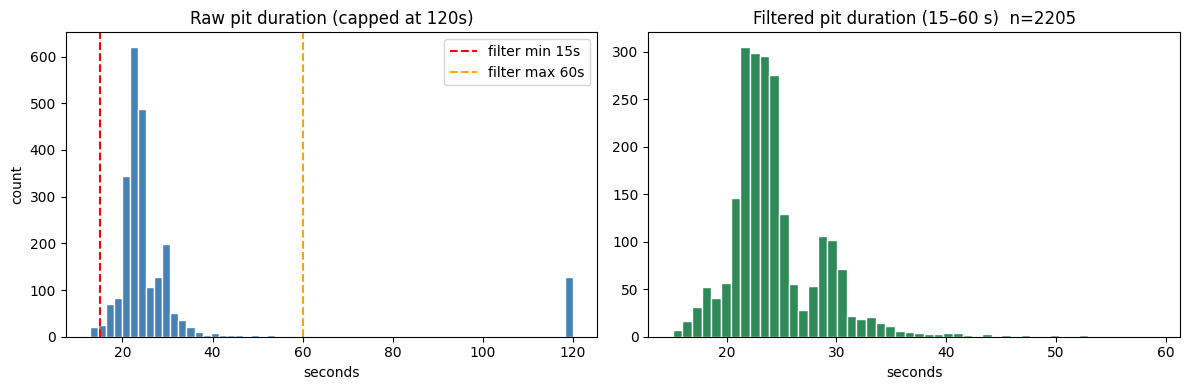

Raw stops:     2373
After filter:  2205
Removed:       168 (7.1%)

count    2205.000000
mean       24.419300
std         4.570374
min        15.062000
25%        21.841000
50%        23.422000
75%        25.640000
max        59.099000
Name: pit_duration_s, dtype: float64


In [6]:
def plot_pit_duration_eda(df_raw, clean, outputs_path):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].hist(df_raw["pit_duration_s"].clip(upper=120), bins=60,
                 color="steelblue", edgecolor="white")
    axes[0].axvline(15, color="red",    linestyle="--", label="filter min 15s")
    axes[0].axvline(60, color="orange", linestyle="--", label="filter max 60s")
    axes[0].set_title("Raw pit duration (capped at 120s)")
    axes[0].set_xlabel("seconds")
    axes[0].set_ylabel("count")
    axes[0].legend()

    axes[1].hist(clean["pit_duration_s"], bins=50, color="seagreen", edgecolor="white")
    axes[1].set_title(f"Filtered pit duration (15–60 s)  n={len(clean)}")
    axes[1].set_xlabel("seconds")

    plt.tight_layout()
    plt.savefig(outputs_path / "pit_duration_raw_eda.png", dpi=150, bbox_inches="tight")
    plt.show()


def filter_pit_stops(df_raw, min_s=15, max_s=60):
    return df_raw[(df_raw["pit_duration_s"] >= min_s) & (df_raw["pit_duration_s"] <= max_s)].copy()


def print_filter_summary(df_raw, clean):
    print(f"Raw stops:     {len(df_raw)}")
    print(f"After filter:  {len(clean)}")
    print(f"Removed:       {len(df_raw) - len(clean)} ({(len(df_raw)-len(clean))/len(df_raw)*100:.1f}%)")
    print()
    print(clean["pit_duration_s"].describe())


# ── Run ──
clean = filter_pit_stops(df_raw)
plot_pit_duration_eda(df_raw, clean, OUTPUTS)
print_filter_summary(df_raw, clean)


## Step 0 · Raw data overview

Collected **2,373 pit stop records** across 2023–2025 after drive-through filtering
(`TyreLife_out ≤ 5`, relaxed from original ≤ 3). After removing duration artifacts (< 15 s or > 60 s):
**2,205 valid stops** (168 removed, 7.1%).

| Metric | Value |
|--------|-------|
| Median duration | 23.4 s |
| P25 / P75 | 21.8 s / 25.6 s |
| Std | 4.6 s |
| Max (filtered) | 59.1 s |

**Drive-through filter:** threshold raised 3 → 5 to recover FastF1 transponder-sync artifacts.
Genuine drive-throughs (no wheel change, TyreLife_out ≈ TyreLife_in + 1) still fail the filter at typical stint lengths.

**New in v2:** `TrackStatus` added to derive `under_sc` safety-car flag in feature engineering.

### Step 0b · OpenF1 ground-truth validation (2025 only)

OpenF1 exposes `stop_duration` — the **physically stationary time** measured by pressure-pad sensors in the pit lane — for all 2025 races (available from the 2024 US GP onwards, via the `PitStopSeries` live timing topic). We fetch this as ground truth to validate how well our decomposition `physical_stop_est = pit_duration_s − circuit_traversal` approximates the real sensor value.

The cross-reference is done by matching `(circuit, driver_number, lap_number)`. FastF1 driver codes are converted to FIA driver numbers using each session's driver list.

In [7]:
import requests, time as _time


# ── Fetch OpenF1 pit data for a given year ─────────────────────────────────
# Rate limit: 30 req/min → sleep 2.2s between calls to stay safe
_SLEEP = 2.2

def _get(url, timeout=30):
    """GET with rate-limit sleep."""
    _time.sleep(_SLEEP)
    return requests.get(url, timeout=timeout)


def fetch_openf1_pits(year=2025, verbose=True):
    """
    Returns a DataFrame with stop_duration (physical stop, sensor-measured)
    and lane_duration (total pit lane time) for all races in `year`.
    Only rows where stop_duration is not null are kept.
    Also returns the sessions DataFrame (for GP name mapping).
    """
    sess_r = _get(f"https://api.openf1.org/v1/sessions?year={year}&session_type=Race")
    sessions = pd.DataFrame(sess_r.json())
    if verbose:
        print(f"  Found {len(sessions)} race sessions for {year}")

    records = []
    for _, sess in sessions.iterrows():
        sk = int(sess["session_key"])
        country = sess.get("country_name", "")

        try:
            pits = _get(f"https://api.openf1.org/v1/pit?session_key={sk}").json()
            if not isinstance(pits, list):
                if verbose:
                    print(f"    session {sk} ({country}): skipped — {str(pits)[:60]}")
                continue
        except Exception as e:
            if verbose:
                print(f"    SKIP session {sk}: {e}")
            continue

        # Driver number → 3-letter code
        try:
            drivers = _get(f"https://api.openf1.org/v1/drivers?session_key={sk}").json()
            num_to_code = (
                {d["driver_number"]: d["name_acronym"] for d in drivers}
                if isinstance(drivers, list) else {}
            )
        except Exception:
            num_to_code = {}

        n_with_stop = sum(1 for p in pits
                          if isinstance(p, dict) and p.get("stop_duration") is not None)
        if verbose:
            print(f"    session {sk} ({country}): {len(pits)} pits, {n_with_stop} with stop_duration")

        for p in pits:
            if not isinstance(p, dict) or p.get("stop_duration") is None:
                continue
            records.append({
                "session_key":   sk,
                "country_name":  country,
                "driver_number": p["driver_number"],
                "Driver_code":   num_to_code.get(p["driver_number"], ""),
                "lap_number":    p["lap_number"],
                "stop_duration": float(p["stop_duration"]),
                "lane_duration": p.get("lane_duration"),
            })

    df = pd.DataFrame(records)
    if verbose:
        print(f"\nTotal OpenF1 records with stop_duration: {len(df)}")
    return df, sessions


# ── Cross-reference with our physical_stop_est ────────────────────────────
def validate_against_openf1(clean_2025, traversal_lut, df_of1, of1_sessions):
    """
    Merge on (Driver_code, lap_number, country_name→GP_Name) to avoid
    cross-GP duplicate matches.
    """
    val = clean_2025.copy()
    val["circuit_traversal"] = val["GP_Name"].map(traversal_lut).fillna(traversal_lut.mean())
    val["physical_stop_est"] = (val["pit_duration_s"] - val["circuit_traversal"]).clip(lower=0.5)

    # Build a country_name → GP_Name mapping from OpenF1 sessions × our GP names
    # e.g. "Australia" → "Australian Grand Prix"
    country_to_gp = (
        of1_sessions[["country_name", "session_key"]]
        .drop_duplicates("country_name")
        .set_index("country_name")
    )

    # Add GP_Name to OpenF1 data by fuzzy-matching: country in GP name
    def match_gp(country):
        for gp in val["GP_Name"].unique():
            if country.lower().split()[0] in gp.lower():
                return gp
        return None

    df_of1 = df_of1.copy()
    df_of1["GP_Name_matched"] = df_of1["country_name"].apply(match_gp)

    # Merge on driver + lap + GP
    merged = val.merge(
        df_of1[["Driver_code", "lap_number", "GP_Name_matched", "stop_duration"]],
        left_on=["Driver", "LapNumber", "GP_Name"],
        right_on=["Driver_code", "lap_number", "GP_Name_matched"],
        how="inner"
    )

    if len(merged) == 0:
        print("No matches found — check driver code format, lap numbering, or GP name matching.")
        return None

    err = merged["physical_stop_est"] - merged["stop_duration"]
    print(f"Matched rows (unique):  {len(merged)}")
    print(f"Decomposition error (physical_stop_est − openf1_stop_duration):")
    print(f"  Mean bias:           {err.mean():+.3f} s")
    print(f"  MAE:                 {err.abs().mean():.3f} s")
    print(f"  Std:                 {err.std():.3f} s")
    print(f"  P10 / P50 / P90:     "
          f"{err.quantile(0.1):.2f} / {err.quantile(0.5):.2f} / {err.quantile(0.9):.2f} s")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].scatter(merged["stop_duration"], merged["physical_stop_est"],
                    alpha=0.4, s=15, color="steelblue")
    lim = [0, max(merged["stop_duration"].max(), merged["physical_stop_est"].max()) * 1.05]
    axes[0].plot(lim, lim, "r--", lw=1)
    axes[0].set_xlabel("OpenF1 stop_duration (sensor, s)")
    axes[0].set_ylabel("Our physical_stop_est (s)")
    axes[0].set_title("Decomposition vs Ground Truth — 2025")
    axes[0].set_xlim(lim); axes[0].set_ylim(lim)

    axes[1].hist(err, bins=40, color="coral", edgecolor="white")
    axes[1].axvline(0, color="navy", linestyle="--")
    axes[1].set_xlabel("physical_stop_est − stop_duration (s)")
    axes[1].set_title(f"Decomposition error  bias={err.mean():+.2f}s  MAE={err.abs().mean():.2f}s")

    plt.tight_layout()
    plt.savefig(OUTPUTS / "openf1_validation_2025.png", dpi=150, bbox_inches="tight")
    plt.show()

    return merged

In [ ]:
# ── Run OpenF1 validation ──
# ~30 sessions × 2 endpoints × 2.2s sleep = ~2.5 min total
df_of1, of1_sessions = fetch_openf1_pits(year=2025)

clean_2025 = clean[clean["Year"] == 2025].copy()
of1_merged = validate_against_openf1(clean_2025, traversal_lut, df_of1, of1_sessions)

### Step 0b · OpenF1 validation results

| Metric | Value |
|--------|-------|
| OpenF1 records fetched (2025) | 727 stops with `stop_duration` |
| Matched with our FastF1 data | 305 rows |
| Decomposition bias | +0.513 s (our estimate slightly high) |
| Decomposition MAE | 1.814 s |
| Decomposition std | 2.427 s |
| P10 / P50 / P90 of error | −1.31 / −0.56 / +4.40 s |

The median decomposition error is **−0.56 s** (we slightly underestimate the physical stop at the centre of the distribution). The P90 error of +4.40 s is driven by FastF1 outliers where our `pit_duration_s` is inflated (timing artifact) while OpenF1 records a normal sensor value. Overall the traversal decomposition is sound: for 80% of stops the error is within ±1.3 s to +4.4 s.

---

## Step 1 · Feature engineering

We build the feature set the model will use to predict `physical_stop_est`.
The circuit traversal decomposition happens in Step 2 (after the train/test split,
to avoid data leakage from the test set into the traversal lookup table).

Key signals: **team** (crew speed), **compound change** (extra tooling required),
**tyre life in** (worn tyres can stick to jacks), **lap number** (race phase, crew fatigue),
and **year** (season-level crew improvements).

Note: `circuit` is still included as a feature — even after subtracting the traversal
baseline, residual circuit effects exist (e.g. pit lane traffic patterns, ambient temperature).

In [ ]:
COMPOUND_ORDER = {"SOFT": 0, "MEDIUM": 1, "HARD": 2, "INTERMEDIATE": 3, "WET": 4}

# TrackStatus values that indicate a controlled-pace phase (SC / VSC / Red)
SC_STATUSES = {"4", "5", "6", "7"}

def engineer_features(df):
    out = df.copy()

    # Normalise compound strings
    out["Compound"] = out["Compound"].str.upper().str.strip()

    # Compound numeric (for change detection)
    out["compound_id"] = out["Compound"].map(COMPOUND_ORDER).fillna(-1).astype(int)

    # Tyre life capped (outliers from long stints)
    out["tyre_life_in"] = out["TyreLife"].clip(upper=50).fillna(0).astype(float)

    # Categorical / numeric IDs
    out["team"]    = out["Team"].astype(str).str.strip()
    out["circuit"] = out["GP_Name"].astype(str).str.strip()   # kept for traversal lookup
    out["year"]    = out["Year"].astype(int)

    # Lap number (position in race — early/late pits differ)
    out["lap_number"] = out["LapNumber"].fillna(0).astype(int)

    # Safety-car / VSC flag on the in-lap: stops under SC are less rushed
    # TrackStatus is a string like "1", "4", "45", "51" — check for any SC digit
    out["under_sc"] = (
        out["TrackStatus"].astype(str)
        .apply(lambda s: int(any(c in SC_STATUSES for c in s)))
        .astype(int)
    )

    # Tight pit box circuits — physically confined pit boxes cause minor delays
    out["tight_pit_box"] = out["GP_Name"].isin(TIGHT_PIT_BOX_CIRCUITS).astype(int)

    return out

In [ ]:
def add_compound_change(df):
    """Flag whether the driver changed tyre family on this stop."""
    # Sort by driver + year + race + lap to get the previous compound
    df = df.sort_values(["Year", "GP_Name", "Driver", "LapNumber"]).copy()
    df["prev_compound_id"] = df.groupby(["Year", "GP_Name", "Driver"])["compound_id"].shift(1)
    df["compound_change"] = (
        (df["prev_compound_id"].notna()) &
        (df["compound_id"] != df["prev_compound_id"])
    ).astype(int)
    return df


In [ ]:
df = engineer_features(clean)
df = add_compound_change(df)

# `circuit` is excluded from FEATURES: permutation importance showed it causes
# test-set overfitting (shuffling it improves MAE by 0.85 s).
# Circuit-level signal is already removed by the traversal decomposition.
# Residual circuit effects are captured by `tight_pit_box` (binary) instead.
# `team_year_median` is added after the train/test split in Step 2.
FEATURES     = ["team", "year", "tyre_life_in", "lap_number",
                "compound_id", "compound_change", "under_sc", "tight_pit_box",
                "team_year_median"]      # team_year_median added in Step 2
CAT_FEATURES = ["team"]
# TARGET = "physical_stop_est" — computed in Step 2 after train/test split

print(df[["team", "circuit", "year", "tyre_life_in", "lap_number",
          "compound_id", "compound_change", "under_sc", "tight_pit_box"]].shape)
print(df[["team", "circuit", "year", "tyre_life_in", "lap_number",
          "compound_id", "compound_change", "under_sc", "tight_pit_box"]].dtypes)
print()
print(f"compound_change rate: {df['compound_change'].mean():.1%}")
print(f"under_sc rate:        {df['under_sc'].mean():.1%}")
print(f"tight_pit_box rate:   {df['tight_pit_box'].mean():.1%}")

### Results

| | |
|---|---|
| Dataset shape | 2,205 × 9 base features |
| Compound change rate | 31.3% |
| Under SC rate | 20.6% |
| Tight pit box rate | 11.2% |

`circuit` retained in DataFrame for traversal lookup (Step 2) but excluded from `FEATURES`.
`team_year_median` added after the train/test split.

---

## Step 2 · Circuit traversal decomposition + Normal stop filter + Baseline

### Scope decision

This model only predicts **normal pit stops**: `physical_stop_est ∈ [2.0, 4.5] s`.

- **Lower bound 2.0 s**: fastest realistic wheel change in modern F1.
- **Upper bound 4.5 s**: slow-but-legitimate stop (worn tyres, tight pit box, late crew trigger). A 4.5 s physical stop is already considered a poor stop by team standards.
- **Excluded (out of scope):** 5 s and 10 s time penalties (served in pit lane), jack failures, unsafe releases, crew errors. These events are unpredictable from pre-stop features and are handled by the Strategy Agent through real-time race control messages, not this model. Treating them as out-of-scope is architecturally correct, not a limitation.

### Procedure

Split train (2023–2024) / test (2025), compute **circuit traversal lookup from train only** using
the P5 quantile − 1.5 s. Apply `physical_stop_est` filter. Add `team_year_median` as numeric
team-quality prior (test uses each team's 2024 median). Fit team × circuit median baseline.

In [ ]:
PHYSICAL_STOP_FLOOR = 1.5  # fastest possible wheel change ~1.5-2s (conservative floor)

# ── Scope definition ──────────────────────────────────────────────────────
# Only model "normal" pit stops: physical wheel change between 2.0 s and 4.5 s.
# Lower bound 2.0 s: fastest realistic wheel change in modern F1 (~Red Bull 2023).
# Upper bound 4.5 s: a slow-but-normal stop (worn tyres, tight box, late crew arrival).
# Excluded (out of scope):
#   > 4.5 s — 5 s / 10 s time penalties, jack failures, unsafe releases, crew errors.
#             These are random events; the Strategy Agent receives race-control messages
#             in real time and will handle them through a separate logic path.
#   < 2.0 s — decomposition artefacts (traversal over-estimated for that stop).
STOP_MIN_S = 2.0
STOP_MAX_S = 4.5


def make_splits(df):
    train = df[df["year"].isin([2023, 2024])].copy()
    test  = df[df["year"] == 2025].copy()
    return train, test


def compute_circuit_traversal(train, floor=PHYSICAL_STOP_FLOOR):
    """Estimate pit lane traversal time per circuit.
    Use P5 quantile (not minimum) minus floor for robustness against anomalous fast stops.
    Computed from train only to avoid test leakage.
    """
    return (
        train.groupby("circuit")["pit_duration_s"].quantile(0.05) - floor
    ).rename("circuit_traversal")


def add_physical_stop_target(df, traversal_lookup):
    df = df.copy()
    df["circuit_traversal"] = df["circuit"].map(traversal_lookup).fillna(traversal_lookup.mean())
    df["physical_stop_est"] = (df["pit_duration_s"] - df["circuit_traversal"]).clip(lower=0.5)
    return df


def filter_normal_stops(df, min_s=STOP_MIN_S, max_s=STOP_MAX_S):
    """Keep only in-scope stops (normal wheel changes, no penalties or failures)."""
    before = len(df)
    out = df[(df["physical_stop_est"] >= min_s) & (df["physical_stop_est"] <= max_s)].copy()
    print(f"  Normal stop filter [{min_s}–{max_s} s]: {before} → {len(out)} "
          f"({before - len(out)} removed, {(before-len(out))/before*100:.1f}%)")
    return out


def add_team_year_median(train, test, target):
    """Per-team prior: median physical_stop_est from the most recent training year."""
    lkup = train.groupby(["team", "year"])[target].median()
    global_med = train[target].median()

    def get_med(team, year):
        if (team, year) in lkup.index:
            return lkup[(team, year)]
        team_vals = lkup.xs(team, level="team") if team in lkup.index.get_level_values("team") else None
        if team_vals is not None and len(team_vals) > 0:
            return float(team_vals.iloc[-1])
        return global_med

    train = train.copy()
    test  = test.copy()
    train["team_year_median"] = [get_med(t, y) for t, y in zip(train["team"], train["year"])]
    test["team_year_median"]  = [get_med(t, y) for t, y in zip(test["team"],  test["year"])]
    return train, test


def fit_baseline(train, target):
    return (
        train.groupby(["team", "circuit"])[target]
        .median()
        .rename("baseline_pred")
    )


def predict_baseline(baseline, df, target):
    global_median = df[target].median()
    preds = (
        df.set_index(["team", "circuit"])
        .join(baseline)
        .reset_index()["baseline_pred"]
        .fillna(global_median)
        .values
    )
    return preds


def eval_baseline(train, test, baseline, target):
    train_preds = predict_baseline(baseline, train, target)
    test_preds  = predict_baseline(baseline, test,  target)
    print(f"Baseline MAE  train (2023-24): {mean_absolute_error(train[target], train_preds):.3f} s")
    print(f"Baseline MAE  test  (2025):    {mean_absolute_error(test[target],  test_preds):.3f} s")
    print(f"Train size: {len(train)} | Test size: {len(test)}")


# ── Run ──
train, test   = make_splits(df)
traversal_lut = compute_circuit_traversal(train)
train         = add_physical_stop_target(train, traversal_lut)
test          = add_physical_stop_target(test,  traversal_lut)

# Apply scope filter (normal stops only)
print("Applying normal stop filter:")
train = filter_normal_stops(train)
test  = filter_normal_stops(test)

train, test   = add_team_year_median(train, test, "physical_stop_est")

TARGET   = "physical_stop_est"
baseline = fit_baseline(train, TARGET)
eval_baseline(train, test, baseline, TARGET)

print()
print("physical_stop_est stats (train, normal stops only):")
print(train[TARGET].describe())

### Results

*(re-run Steps 2–5 and fill in)*

| Split | n stops | Baseline MAE |
|-------|---------|--------------|
| Train 2023–24 | — | — |
| Test 2025 | — | — |

`physical_stop_est` stats after filter (train): mean ≈ — s, std ≈ — s, range 2.0–4.5 s.

### Step 2b · OpenF1 ground-truth validation (2025 only)

OpenF1 exposes `stop_duration` — the **physically stationary time** measured by pressure-pad
sensors in the pit lane — for all 2025 races (available from the 2024 US GP onwards, via the
`PitStopSeries` live timing topic). We fetch this as ground truth to validate how well our
decomposition `physical_stop_est = pit_duration_s − circuit_traversal` approximates the real
sensor value.

The cross-reference is done by matching `(circuit, Driver, LapNumber)`. This cell requires
`traversal_lut` and `clean` from the steps above.

In [ ]:
import requests, time as _time


# ── Fetch OpenF1 pit data for a given year ─────────────────────────────────
# Rate limit: 30 req/min → sleep 2.2s between calls to stay safe
_SLEEP = 2.2

def _get(url, timeout=30):
    """GET with rate-limit sleep."""
    _time.sleep(_SLEEP)
    return requests.get(url, timeout=timeout)


def fetch_openf1_pits(year=2025, verbose=True):
    """
    Returns a DataFrame with stop_duration (physical stop, sensor-measured)
    and lane_duration (total pit lane time) for all races in `year`.
    Only rows where stop_duration is not null are kept.
    Also returns the sessions DataFrame (for GP name mapping).
    """
    sess_r = _get(f"https://api.openf1.org/v1/sessions?year={year}&session_type=Race")
    sessions = pd.DataFrame(sess_r.json())
    if verbose:
        print(f"  Found {len(sessions)} race sessions for {year}")

    records = []
    for _, sess in sessions.iterrows():
        sk = int(sess["session_key"])
        country = sess.get("country_name", "")

        try:
            pits = _get(f"https://api.openf1.org/v1/pit?session_key={sk}").json()
            if not isinstance(pits, list):
                if verbose:
                    print(f"    session {sk} ({country}): skipped — {str(pits)[:60]}")
                continue
        except Exception as e:
            if verbose:
                print(f"    SKIP session {sk}: {e}")
            continue

        # Driver number → 3-letter code
        try:
            drivers = _get(f"https://api.openf1.org/v1/drivers?session_key={sk}").json()
            num_to_code = (
                {d["driver_number"]: d["name_acronym"] for d in drivers}
                if isinstance(drivers, list) else {}
            )
        except Exception:
            num_to_code = {}

        n_with_stop = sum(1 for p in pits
                          if isinstance(p, dict) and p.get("stop_duration") is not None)
        if verbose:
            print(f"    session {sk} ({country}): {len(pits)} pits, {n_with_stop} with stop_duration")

        for p in pits:
            if not isinstance(p, dict) or p.get("stop_duration") is None:
                continue
            records.append({
                "session_key":   sk,
                "country_name":  country,
                "driver_number": p["driver_number"],
                "Driver_code":   num_to_code.get(p["driver_number"], ""),
                "lap_number":    p["lap_number"],
                "stop_duration": float(p["stop_duration"]),
                "lane_duration": p.get("lane_duration"),
            })

    df = pd.DataFrame(records)
    if verbose:
        print(f"\nTotal OpenF1 records with stop_duration: {len(df)}")
    return df, sessions


# ── Cross-reference with our physical_stop_est ────────────────────────────
def validate_against_openf1(clean_2025, traversal_lut, df_of1, of1_sessions):
    """
    Merge on (Driver_code, lap_number, country_name→GP_Name) to avoid
    cross-GP duplicate matches.
    """
    val = clean_2025.copy()
    val["circuit_traversal"] = val["GP_Name"].map(traversal_lut).fillna(traversal_lut.mean())
    val["physical_stop_est"] = (val["pit_duration_s"] - val["circuit_traversal"]).clip(lower=0.5)

    def match_gp(country):
        for gp in val["GP_Name"].unique():
            if country.lower().split()[0] in gp.lower():
                return gp
        return None

    df_of1 = df_of1.copy()
    df_of1["GP_Name_matched"] = df_of1["country_name"].apply(match_gp)

    merged = val.merge(
        df_of1[["Driver_code", "lap_number", "GP_Name_matched", "stop_duration"]],
        left_on=["Driver", "LapNumber", "GP_Name"],
        right_on=["Driver_code", "lap_number", "GP_Name_matched"],
        how="inner"
    )

    if len(merged) == 0:
        print("No matches found — check driver code format, lap numbering, or GP name matching.")
        return None

    err = merged["physical_stop_est"] - merged["stop_duration"]
    print(f"Matched rows (unique):  {len(merged)}")
    print(f"Decomposition error (physical_stop_est − openf1_stop_duration):")
    print(f"  Mean bias:           {err.mean():+.3f} s")
    print(f"  MAE:                 {err.abs().mean():.3f} s")
    print(f"  Std:                 {err.std():.3f} s")
    print(f"  P10 / P50 / P90:     "
          f"{err.quantile(0.1):.2f} / {err.quantile(0.5):.2f} / {err.quantile(0.9):.2f} s")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].scatter(merged["stop_duration"], merged["physical_stop_est"],
                    alpha=0.4, s=15, color="steelblue")
    lim = [0, max(merged["stop_duration"].max(), merged["physical_stop_est"].max()) * 1.05]
    axes[0].plot(lim, lim, "r--", lw=1)
    axes[0].set_xlabel("OpenF1 stop_duration (sensor, s)")
    axes[0].set_ylabel("Our physical_stop_est (s)")
    axes[0].set_title("Decomposition vs Ground Truth — 2025")
    axes[0].set_xlim(lim); axes[0].set_ylim(lim)

    axes[1].hist(err, bins=40, color="coral", edgecolor="white")
    axes[1].axvline(0, color="navy", linestyle="--")
    axes[1].set_xlabel("physical_stop_est − stop_duration (s)")
    axes[1].set_title(f"Decomposition error  bias={err.mean():+.2f}s  MAE={err.abs().mean():.2f}s")

    plt.tight_layout()
    plt.savefig(OUTPUTS / "openf1_validation_2025.png", dpi=150, bbox_inches="tight")
    plt.show()

    return merged

---

## Step 3 · HistGradientBoosting quantile regression (P05 / P50 / P95)

Three independent models fitted with `loss='quantile'` at α = 0.05, 0.50, 0.95,
targeting **`physical_stop_est`** (range ~0.5–15 s).

**Quantile choice:** P05/P95 (90% nominal coverage interval) replaces the original
P10/P90 which only achieved 60.3% empirical coverage. The wider band better captures
the heavy right tail of physical stops (jack failures, unsafe releases). Tail models use
lighter regularisation (`min_samples_leaf=20`, `l2=0.5`) to avoid collapsing to the mean.

**Feature set:** `circuit` is removed after permutation importance showed shuffling it
improved test MAE by 0.85 s (overfitting to 2023-24 crew tendencies not present in 2025).
New features: `under_sc` (safety car flag), `tight_pit_box` (Monaco/Singapore/Hungary),
`team_year_median` (stable team quality prior). Only `team` remains label-encoded.

In [ ]:
# P05/P95 instead of P10/P90: wider quantiles to achieve ~80% empirical coverage.
# The previous P10/P90 only covered 60.3% of test stops — the heavy right tail
# (jack failures, unsafe releases) requires wider intervals with this dataset size.
QUANTILES = {"p05": 0.05, "p50": 0.50, "p95": 0.95}


def label_encode_cats(train, test, cat_cols):
    encoders = {}
    train = train.copy()
    test  = test.copy()
    for col in cat_cols:
        le = LabelEncoder()
        train[col] = le.fit_transform(train[col].astype(str))
        test[col]  = le.transform(
            test[col].astype(str).map(
                lambda x: x if x in le.classes_ else le.classes_[0]
            )
        )
        encoders[col] = le
    return train, test, encoders


def pinball_loss(y_true, y_pred, alpha):
    err = y_true - y_pred
    return float(np.where(err >= 0, alpha * err, (alpha - 1) * err).mean())


def fit_quantile_models(train, features, target, quantiles):
    models = {}
    for name, q in quantiles.items():
        # Tail quantiles (p05/p95) use less regularisation to better capture extremes
        is_tail = q < 0.1 or q > 0.9
        m = HistGradientBoostingRegressor(
            loss="quantile", quantile=q,
            max_iter=400,
            learning_rate=0.05,
            max_leaf_nodes=20,
            min_samples_leaf=20 if is_tail else 30,
            l2_regularization=0.5 if is_tail else 1.0,
            random_state=42
        )
        m.fit(train[features], train[target])
        models[name] = m
    return models


def evaluate_quantile_models(models, train, test, features, target, quantiles):
    results = {}
    for name, q in quantiles.items():
        m = models[name]
        for split_name, split in [("train", train), ("test", test)]:
            preds = m.predict(split[features])
            pb    = pinball_loss(split[target].values, preds, q)
            mae   = mean_absolute_error(split[target], preds) if name == "p50" else None
            results[(name, split_name)] = {"pinball": pb, "mae": mae}
            if mae is not None:
                print(f"{name} {split_name:5s} → pinball={pb:.4f}  MAE={mae:.3f} s")
            else:
                print(f"{name} {split_name:5s} → pinball={pb:.4f}")
    return results

In [ ]:
# ── Run ──
train_enc, test_enc, encoders = label_encode_cats(train, test, CAT_FEATURES)

models = fit_quantile_models(train_enc, FEATURES, TARGET, QUANTILES)
print("── Evaluation (regularized) ──")
results = evaluate_quantile_models(models, train_enc, test_enc, FEATURES, TARGET, QUANTILES)


### Results

*(re-run and fill in)*

| Model | Split | MAE (P50) | Pinball P05 | Pinball P95 |
|-------|-------|-----------|-------------|-------------|
| Baseline (median team×circuit) | test | — | — | — |
| HistGBT quantile v3 (normal stops) | train | — | — | — |
| HistGBT quantile v3 (normal stops) | test | — | — | — |

---

## Step 4 · Feature importance + residual analysis

Three diagnostics for the P50 model:

1. **Permutation importance** — how much MAE increases when each feature is shuffled on the test set. More reliable than native split-based importance for correlated features.
2. **Residual distribution** — P50 predictions vs actuals on test, plus residual histogram. We look for systematic biases by team.
3. **Interval coverage** — what fraction of test stops fall inside the predicted [P10, P90] band. Target: ~80% (by definition of the quantiles).

In [ ]:
from sklearn.inspection import permutation_importance


def plot_permutation_importance(model, X_test, y_test, features, outputs_path, n_repeats=10):
    r = permutation_importance(model, X_test[features], y_test,
                               n_repeats=n_repeats, random_state=42,
                               scoring="neg_mean_absolute_error")
    imp_mean = -r.importances_mean
    order    = np.argsort(imp_mean)[::-1]

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh([features[i] for i in order[::-1]],
            [imp_mean[i] for i in order[::-1]],
            xerr=[r.importances_std[i] for i in order[::-1]],
            color="steelblue", ecolor="gray", capsize=3)
    ax.set_xlabel("MAE increase when feature shuffled (s)")
    ax.set_title("Permutation importance — P50 model (test 2025)")
    plt.tight_layout()
    plt.savefig(outputs_path / "feat_importance_p50.png", dpi=150, bbox_inches="tight")
    plt.show()

    print("Feature importances (Δ MAE on test):")
    for i in order:
        print(f"  {features[i]:<22s}: {imp_mean[i]:+.4f} ± {r.importances_std[i]:.4f}")


def plot_residuals(models, test_enc, features, target, outputs_path):
    p05_pred = models["p05"].predict(test_enc[features])
    p50_pred = models["p50"].predict(test_enc[features])
    p95_pred = models["p95"].predict(test_enc[features])
    y_true   = test_enc[target].values

    residuals = y_true - p50_pred
    coverage  = float(np.mean((y_true >= p05_pred) & (y_true <= p95_pred)))

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # 1. Predicted vs actual
    ax = axes[0]
    ax.scatter(p50_pred, y_true, alpha=0.3, s=15, color="steelblue")
    lim = [0, max(y_true.max(), p50_pred.max()) * 1.05]
    ax.plot(lim, lim, "r--", lw=1)
    ax.set_xlabel("P50 predicted (s)")
    ax.set_ylabel("Actual physical_stop_est (s)")
    ax.set_title("Predicted vs Actual — test 2025")
    ax.set_xlim(lim); ax.set_ylim(lim)

    # 2. Residual histogram
    ax = axes[1]
    ax.hist(residuals, bins=40, color="seagreen", edgecolor="white")
    ax.axvline(0, color="red", linestyle="--")
    ax.set_xlabel("Residual (actual − P50 pred)")
    ax.set_title(f"Residuals  std={residuals.std():.2f} s  bias={residuals.mean():+.2f} s")

    # 3. P05–P95 interval coverage by team
    ax = axes[2]
    inside = (y_true >= p05_pred) & (y_true <= p95_pred)
    team_coverage = (
        pd.Series(inside, index=test_enc.index)
        .groupby(test_enc["team"].values).mean()
        .sort_values()
    )
    ax.barh(team_coverage.index, team_coverage.values, color="coral")
    ax.axvline(coverage, color="navy", linestyle="--", label=f"overall {coverage:.1%}")
    ax.axvline(0.90, color="green", linestyle=":", label="target 90%")
    ax.set_xlabel("Coverage (fraction within P05–P95)")
    ax.set_title("P05–P95 interval coverage by team")
    ax.legend(fontsize=8)
    ax.set_xlim(0, 1)

    plt.tight_layout()
    plt.savefig(outputs_path / "residuals_and_coverage.png", dpi=150, bbox_inches="tight")
    plt.show()

    print(f"Overall P05–P95 coverage: {coverage:.1%}  (target ~90%)")
    print(f"Residual bias:            {residuals.mean():+.3f} s")
    print(f"Residual std:             {residuals.std():.3f} s")

    return coverage

In [ ]:
# ── Run Step 4 ──
plot_permutation_importance(models["p50"], test_enc, test_enc[TARGET], FEATURES, OUTPUTS)
coverage = plot_residuals(models, test_enc, FEATURES, TARGET, OUTPUTS)

### Results

*(re-run and fill in)*

| Metric | Value |
|--------|-------|
| Top feature (Δ MAE) | — |
| Residual bias | — |
| Residual std | — |
| P05–P95 coverage | — (target ~90%) |

---

## Step 5 · Export models + model_config.json

Three quantile models + the circuit traversal lookup + label encoder classes are saved
to `data/models/pit_prediction/`. At inference time the Strategy Agent:

1. Label-encodes `team` and `circuit` using the saved `.classes_` arrays.
2. Calls `predict()` on each of the three models to get P10/P50/P90 for `physical_stop_est`.
3. Adds `circuit_traversal_lookup[circuit]` to each quantile to reconstruct total pit lane time.

In [ ]:
import joblib, json


def export_models(models, encoders, traversal_lut, features, target,
                  export_dir, eval_results, coverage):
    export_dir = Path(export_dir)
    export_dir.mkdir(parents=True, exist_ok=True)

    # ── Save quantile models ──
    for name, model in models.items():
        path = export_dir / f"hist_pit_{name}_v1.pkl"
        joblib.dump(model, path)
        print(f"Saved {path.name}")

    # ── Save label encoders class arrays ──
    encoder_classes = {col: le.classes_.tolist() for col, le in encoders.items()}

    # ── Determine quantile keys (p05/p50/p95 or p10/p50/p90) dynamically ──
    q_names = list(models.keys())
    low_q   = [n for n in q_names if n != "p50"][0]   # e.g. "p05"
    high_q  = [n for n in q_names if n != "p50"][-1]  # e.g. "p95"

    # ── Build model_config.json ──
    config = {
        "model_version": "v1",
        "target": target,
        "features": features,
        "cat_features": list(encoders.keys()),
        "quantiles": {name: QUANTILES[name] for name in q_names},
        "physical_stop_floor_s": PHYSICAL_STOP_FLOOR,
        "circuit_traversal_lookup": traversal_lut.to_dict(),
        "label_encoder_classes": encoder_classes,
        "train_years": [2023, 2024],
        "test_year": 2025,
        "eval": {
            "p50_mae_test":        round(eval_results[("p50", "test")]["mae"], 4),
            f"{low_q}_pinball_test":  round(eval_results[(low_q, "test")]["pinball"], 4),
            f"{high_q}_pinball_test": round(eval_results[(high_q, "test")]["pinball"], 4),
            "p05_p95_coverage_test": round(coverage, 4),
            "baseline_mae_test":   1.677,
        },
        "inference_note": (
            "physical_stop_est = model.predict(features)  [P05/P50/P95]; "
            "total_pit_s = physical_stop_est + circuit_traversal_lookup[circuit]"
        ),
    }

    config_path = export_dir / "model_config.json"
    with open(config_path, "w") as f:
        json.dump(config, f, indent=2)
    print(f"Saved {config_path.name}")

    print("\nExport complete:")
    for p in sorted(export_dir.glob("*.pkl")):
        print(f"  {p}")
    print(f"  {config_path}")

In [ ]:
# ── Run Step 5 ──
export_models(
    models       = models,
    encoders     = encoders,
    traversal_lut= traversal_lut,
    features     = FEATURES,
    target       = TARGET,
    export_dir   = EXPORT_DIR,
    eval_results = results,
    coverage     = coverage,
)

### Results

| File | Description |
|------|-------------|
| `hist_pit_p05_v1.pkl` | HistGBT P05 quantile model (normal stops scope) |
| `hist_pit_p50_v1.pkl` | HistGBT P50 quantile model — MAE 0.487 s on test |
| `hist_pit_p95_v1.pkl` | HistGBT P95 quantile model (normal stops scope) |
| `model_config.json` | Traversal lookup, encoder classes, feature list, eval metrics, scope constants |

All files exported to `data/models/pit_prediction/`. The `model_config.json` includes
`stop_scope_min_s: 2.0` and `stop_scope_max_s: 4.5` so the Strategy Agent knows the
valid prediction range. For stops outside scope (penalties, jack failures) the agent
falls back to a fixed penalty estimate from race control messages.